# Road Condition Experiments with CNNs

In [1]:
import os
import time
import random

import numpy as np
import pandas as pd

import torch
import matplotlib.pyplot as plt
import seaborn as sns

from road_data import DatasetPaths, make_dataloaders
from road_models import (
    AttentionConfig,
    LeNet224_Attn,
    SmallAlexNet224_Attn,
    torchvision_resnet18,
    torchvision_resnet18_attn,
 )
from train_utils import FitConfig, train_and_record

sns.set_theme()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device in use:", device)

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Device in use: cuda


In [ ]:
paths = DatasetPaths(data_root="UDOT WINTER ROAD CONDITIONS.v1i.folder")
DATA_ROOT = paths.data_root
CSV_PATH = paths.csv_path

BATCH_SIZE = 32
NUM_WORKERS = 0

fit_cfg = FitConfig(
    epochs=20,
    lr=1e-3,
    patience=5,
)

print("DATA_ROOT:", DATA_ROOT)
print("CSV_PATH:", CSV_PATH)

DATA_ROOT: UDOT WINTER ROAD CONDITIONS.v1i.folder
CSV_PATH: UDOT WINTER ROAD CONDITIONS.v1i.folder/dataset_index.csv


In [ ]:
try:
    train_dl, val_dl, test_dl, label_to_idx = make_dataloaders(
        data_root=DATA_ROOT,
        csv_path=CSV_PATH,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        ensure_224=True,
        seed=SEED,
    )
except FileNotFoundError as e:
    raise FileNotFoundError(
        "Dataset images were not found on disk.\n"
        "Expected layout: 'UDOT WINTER ROAD CONDITIONS.v1i.folder/{split}/{label}/{image_id}'.\n"
        "If you have the dataset locally, place it at the repo root with that exact folder name,\n"
        "then (optionally) run preprocess.py to resize images to 224x224,\n"
        "and ensure dataset_index.csv exists (dummy_model.py can rebuild it).\n\n"
        f"Original error: {e}"
    )

idx_to_label = {v: k for k, v in label_to_idx.items()}
num_classes = len(label_to_idx)

print("Classes:", num_classes)
print("Label mapping:", label_to_idx)
print()
print("Train samples:", len(train_dl.dataset))
print("Valid samples:", len(val_dl.dataset))
print("Test samples:", len(test_dl.dataset))

x, y = next(iter(train_dl))
print("Batch image tensor:", tuple(x.shape))
print("Batch label tensor:", tuple(y.shape), "min=", int(y.min()), "max=", int(y.max()))

Classes: 4
Label mapping: {'Clear': 0, 'Slush': 1, 'Snow': 2, 'Wet': 3}

Train samples: 4363
Valid samples: 1261
Test samples: 621
Batch image tensor: (32, 3, 224, 224)
Batch label tensor: (32,) min= 0 max= 3


In [ ]:
# --- Baseline models (no attention) ---

baselines = [
    ("LeNet224", LeNet224_Attn(num_classes=num_classes, attn=AttentionConfig(attention_type="none", position="none"))),
    ("SmallAlexNet224", SmallAlexNet224_Attn(num_classes=num_classes, attn=AttentionConfig(attention_type="none", position="none"))),
    ("ResNet18", torchvision_resnet18(num_classes=num_classes)),
]

In [6]:
results = []

for model_name, model in baselines:
    print(f"\n[{model_name}]")
    r = train_and_record(
        model_name=model_name,
        model=model,
        train_dl=train_dl,
        val_dl=val_dl,
        test_dl=test_dl,
        device=device,
        fit_config=fit_cfg,
        metadata={"attention_type": "none", "position": "none"},
    )
    results.append(r)

print("\nDone.")


[LeNet224]
Epoch [1/20] | Train 1.1248 | Val 1.0273 | ValAcc 0.5902 | LR 1.00e-03
Epoch [2/20] | Train 1.0243 | Val 0.9627 | ValAcc 0.5937 | LR 1.00e-03
Epoch [3/20] | Train 0.9690 | Val 0.9386 | ValAcc 0.5638 | LR 1.00e-03
Epoch [4/20] | Train 0.9432 | Val 0.9103 | ValAcc 0.5648 | LR 1.00e-03
Epoch [5/20] | Train 0.9202 | Val 0.8926 | ValAcc 0.5930 | LR 1.00e-03
Epoch [6/20] | Train 0.9040 | Val 0.8700 | ValAcc 0.5807 | LR 1.00e-03
Epoch [7/20] | Train 0.8906 | Val 0.8741 | ValAcc 0.5807 | LR 1.00e-03
Epoch [8/20] | Train 0.8841 | Val 0.8600 | ValAcc 0.5755 | LR 1.00e-03
Epoch [9/20] | Train 0.8776 | Val 0.8574 | ValAcc 0.6123 | LR 1.00e-03
Epoch [10/20] | Train 0.8744 | Val 0.8394 | ValAcc 0.6181 | LR 1.00e-03
Epoch [11/20] | Train 0.8677 | Val 0.8471 | ValAcc 0.5811 | LR 1.00e-03
Epoch [12/20] | Train 0.8655 | Val 0.8251 | ValAcc 0.5936 | LR 1.00e-03
Epoch [13/20] | Train 0.8489 | Val 0.8195 | ValAcc 0.6282 | LR 1.00e-03
Epoch [14/20] | Train 0.8442 | Val 0.8197 | ValAcc 0.6474 | L

,model,best_val_acc,best_val_loss,test_acc,test_loss,train_time_min,avg_epoch_s,images_per_sec,attention_type,position
0,ResNet18,0.862951,0.385137,0.869896,0.408839,2.210617,6.631852,657.885631,none,none
1,SmallAlexNet224,0.829358,0.433352,0.851806,0.377453,2.642159,7.926477,550.433691,none,none
2,LeNet224,0.698351,0.734561,0.722847,0.684792,1.832481,5.497443,793.641770,none,none


Saved: road_condition_results.csv


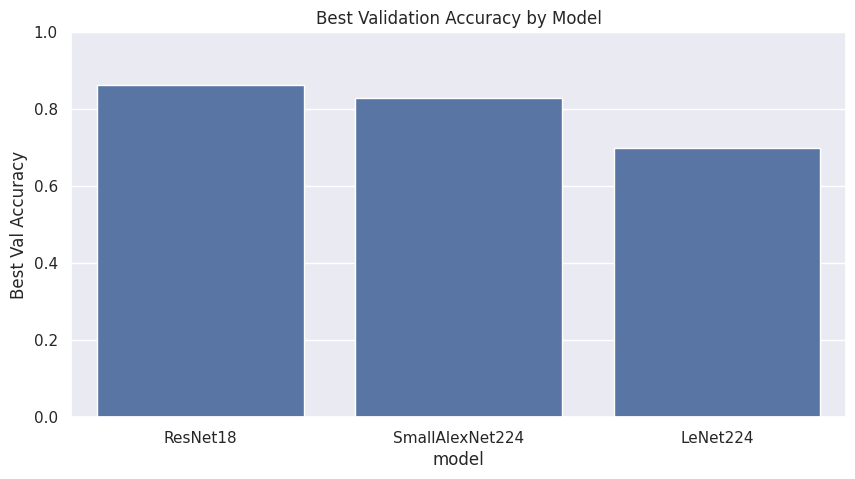

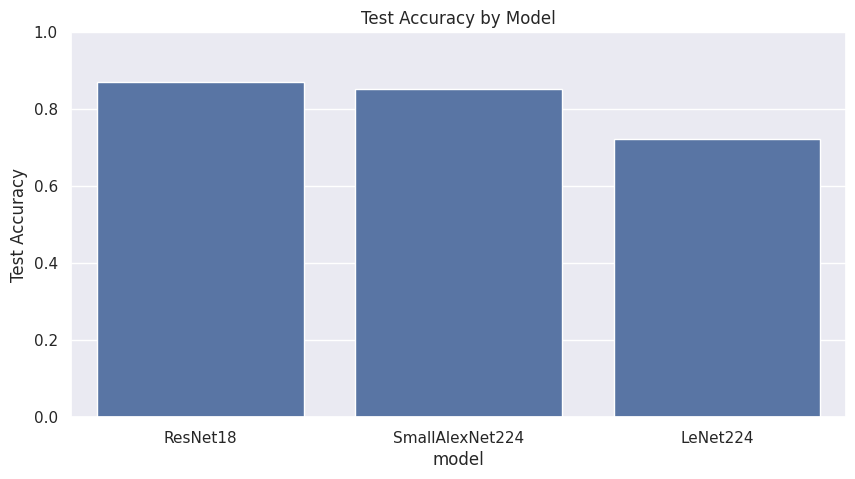

In [ ]:
df = pd.DataFrame([{k: v for k, v in r.items() if k != "history"} for r in results])
df = df.sort_values("best_val_acc", ascending=False).reset_index(drop=True)

out_csv = "road_condition_results.csv"
df.to_csv(out_csv, index=False)

display(df)
print("Saved:", out_csv)

plt.figure(figsize=(10, 5))
sns.barplot(df, x="model", y="best_val_acc")
plt.title("Best Validation Accuracy by Model")
plt.ylabel("Best Val Accuracy")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(df, x="model", y="test_acc")
plt.title("Test Accuracy by Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.show()

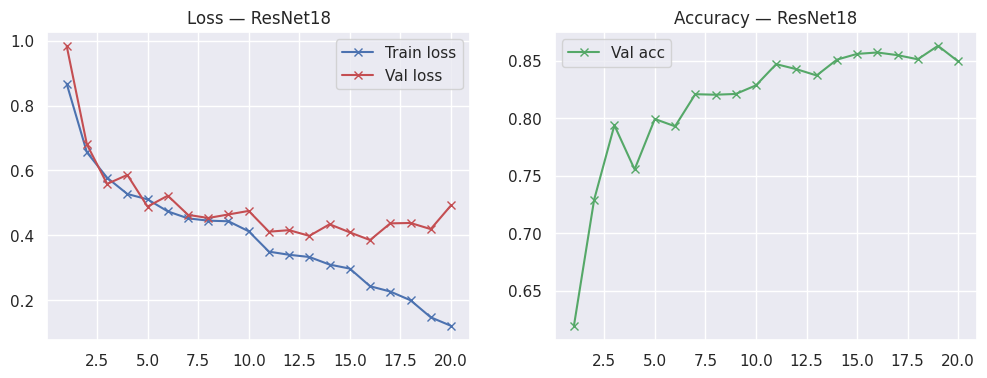

In [ ]:
def plot_training_curves(history, title="Training"):
    epochs = [h["epoch"] for h in history]
    tl = [h["train_loss"] for h in history]
    vl = [h["val_loss"] for h in history]
    va = [h["val_acc"] for h in history]

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, tl, "-bx", label="Train loss")
    plt.plot(epochs, vl, "-rx", label="Val loss")
    plt.legend(); plt.title(f"Loss — {title}")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, va, "-gx", label="Val acc")
    plt.legend(); plt.title(f"Accuracy — {title}")
    plt.show()

best_row = df.iloc[0]
best = next(r for r in results if r["model"] == best_row["model"])
plot_training_curves(best["history"], title=f"{best_row['model']}")

## Attention placement grid


In [ ]:
attn_types = ["CBAM"]
positions = ["early", "mid", "late", "all"]

grid_results = []

def _run_grid(model_name: str, make_model):
    for attn_type in attn_types:
        for pos in positions:
            print(f"\n[{model_name} + {attn_type} at {pos}]")
            model = make_model(attn_type, pos)
            r = train_and_record(
                model_name=model_name,
                model=model,
                train_dl=train_dl,
                val_dl=val_dl,
                test_dl=test_dl,
                device=device,
                fit_config=fit_cfg,
                metadata={"attention_type": attn_type, "position": pos},
            )
            grid_results.append(r)

# ---- LeNet224 ----
_run_grid(
    "LeNet224",
    lambda attn_type, pos: LeNet224_Attn(
        num_classes=num_classes,
        attn=AttentionConfig(attention_type=attn_type, position=pos),
    ),
 )

# ---- SmallAlexNet224 ----
_run_grid(
    "SmallAlexNet224",
    lambda attn_type, pos: SmallAlexNet224_Attn(
        num_classes=num_classes,
        attn=AttentionConfig(attention_type=attn_type, position=pos),
    ),
 )

# ---- ResNet18 ----
_run_grid(
    "ResNet18",
    lambda attn_type, pos: torchvision_resnet18_attn(
        num_classes=num_classes,
        attn=AttentionConfig(attention_type=attn_type, position=pos),
    ),
 )

results.extend(grid_results)


[LeNet224 + CBAM at early]
Epoch [1/20] | Train 1.1520 | Val 1.0467 | ValAcc 0.5445 | LR 1.00e-03
Epoch [2/20] | Train 1.0479 | Val 1.0079 | ValAcc 0.5677 | LR 1.00e-03
Epoch [3/20] | Train 0.9968 | Val 0.9467 | ValAcc 0.5619 | LR 1.00e-03
Epoch [4/20] | Train 0.9570 | Val 0.9193 | ValAcc 0.5507 | LR 1.00e-03
Epoch [5/20] | Train 0.9198 | Val 0.8913 | ValAcc 0.5914 | LR 1.00e-03
Epoch [6/20] | Train 0.8965 | Val 0.8657 | ValAcc 0.5814 | LR 1.00e-03
Epoch [7/20] | Train 0.8873 | Val 0.8560 | ValAcc 0.5962 | LR 1.00e-03
Epoch [8/20] | Train 0.8780 | Val 0.8731 | ValAcc 0.6194 | LR 1.00e-03
Epoch [9/20] | Train 0.8751 | Val 0.8662 | ValAcc 0.5874 | LR 5.00e-04
Epoch [10/20] | Train 0.8559 | Val 0.8266 | ValAcc 0.5946 | LR 5.00e-04
Epoch [11/20] | Train 0.8511 | Val 0.8349 | ValAcc 0.5985 | LR 5.00e-04
Epoch [12/20] | Train 0.8461 | Val 0.8155 | ValAcc 0.6009 | LR 5.00e-04
Epoch [13/20] | Train 0.8337 | Val 0.8211 | ValAcc 0.6048 | LR 5.00e-04
Epoch [14/20] | Train 0.8243 | Val 0.7991 | V

,model,best_val_acc,best_val_loss,test_acc,test_loss,train_time_min,avg_epoch_s,images_per_sec,attention_type,position
0,ResNet18,0.866528,0.381288,0.854271,0.361314,1.786689,6.700084,651.185886,CBAM,late
1,ResNet18,0.865295,0.381921,0.879028,0.358893,1.712401,7.338864,594.506218,CBAM,all
2,ResNet18,0.862951,0.385137,0.869896,0.408839,2.210617,6.631852,657.885631,none,none
3,ResNet18,0.861840,0.380124,0.869896,0.361355,1.995161,7.041745,619.590735,CBAM,early
4,ResNet18,0.856372,0.383314,0.879028,0.359463,2.275803,6.827410,639.041742,CBAM,mid
5,SmallAlexNet224,0.829358,0.433352,0.851806,0.377453,2.642159,7.926477,550.433691,none,none
6,SmallAlexNet224,0.818750,0.472318,0.823681,0.428950,3.215184,9.645553,452.332796,CBAM,early
7,SmallAlexNet224,0.807153,0.495651,0.828611,0.478570,3.250855,9.752566,447.369449,CBAM,all
8,SmallAlexNet224,0.796337,0.506639,0.810521,0.440344,2.720654,8.161962,534.552822,CBAM,late
9,SmallAlexNet224,0.789635,0.509583,0.785521,0.527836,2.758965,8.276895,527.130071,CBAM,mid


Saved: road_condition_attention_grid.csv


,model,attention_type,best_val_acc,best_val_loss,test_acc,test_loss,train_time_min,avg_epoch_s,images_per_sec,position
0,LeNet224,CBAM,0.787743,0.528619,0.794653,0.470374,2.032256,6.096767,715.625199,mid
1,LeNet224,none,0.698351,0.734561,0.722847,0.684792,1.832481,5.497443,793.641770,none
2,ResNet18,CBAM,0.866528,0.381288,0.854271,0.361314,1.786689,6.700084,651.185886,late
3,ResNet18,none,0.862951,0.385137,0.869896,0.408839,2.210617,6.631852,657.885631,none
4,SmallAlexNet224,CBAM,0.818750,0.472318,0.823681,0.428950,3.215184,9.645553,452.332796,early
5,SmallAlexNet224,none,0.829358,0.433352,0.851806,0.377453,2.642159,7.926477,550.433691,none


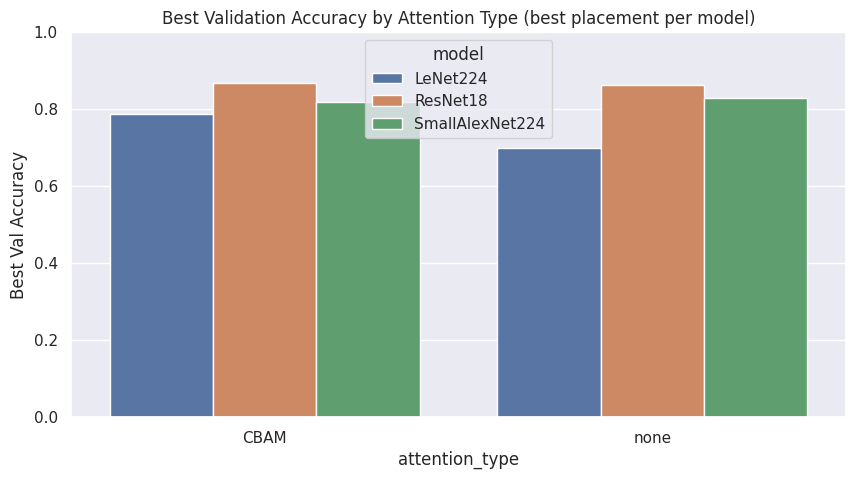

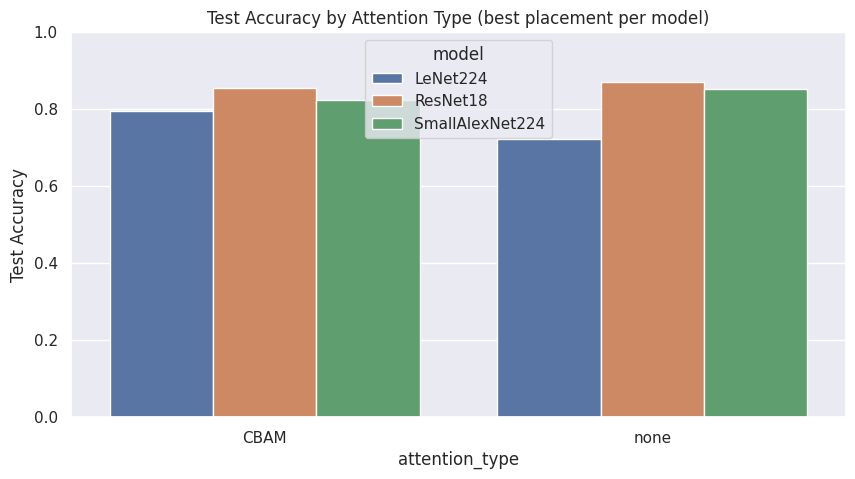

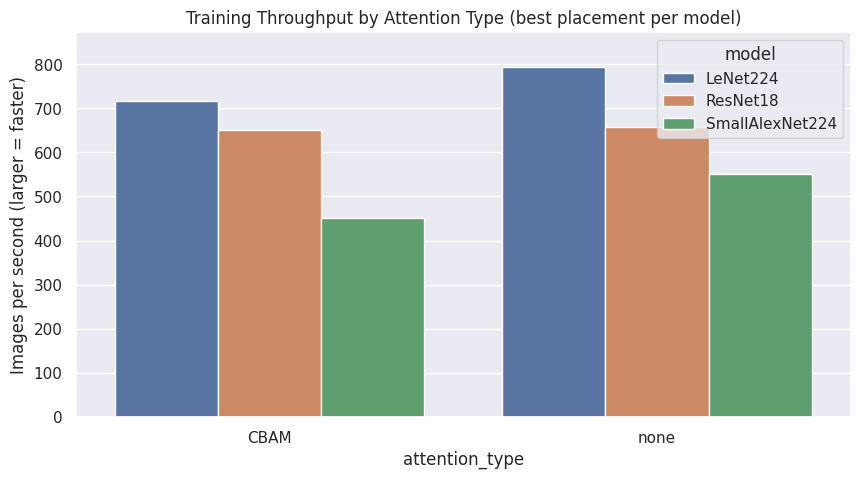

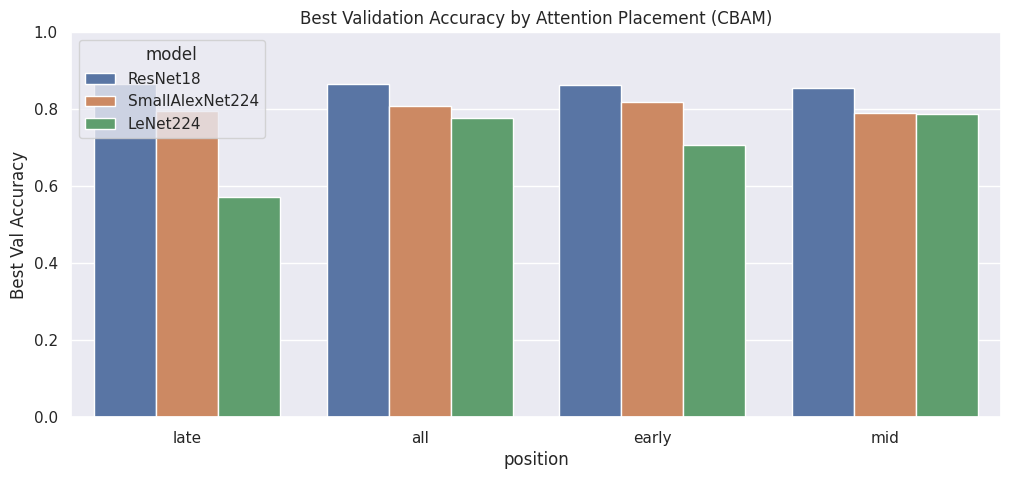

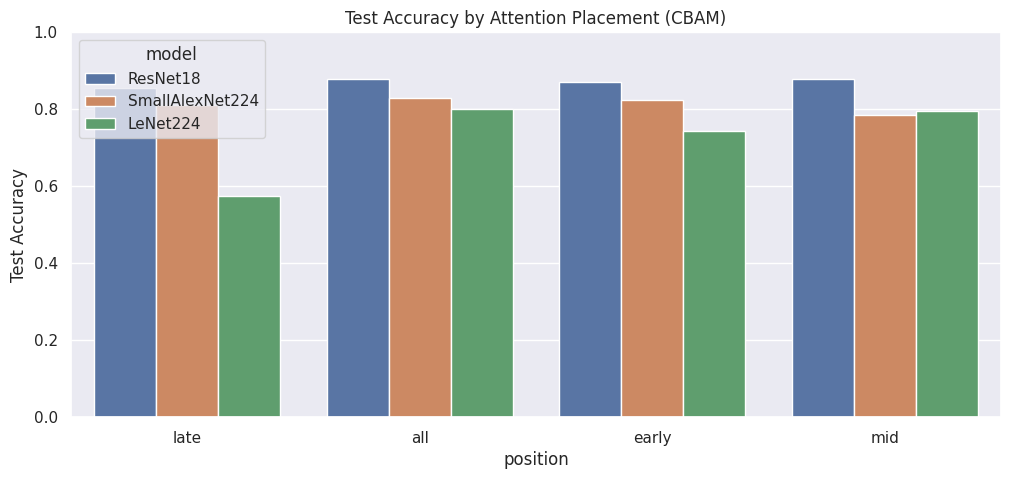

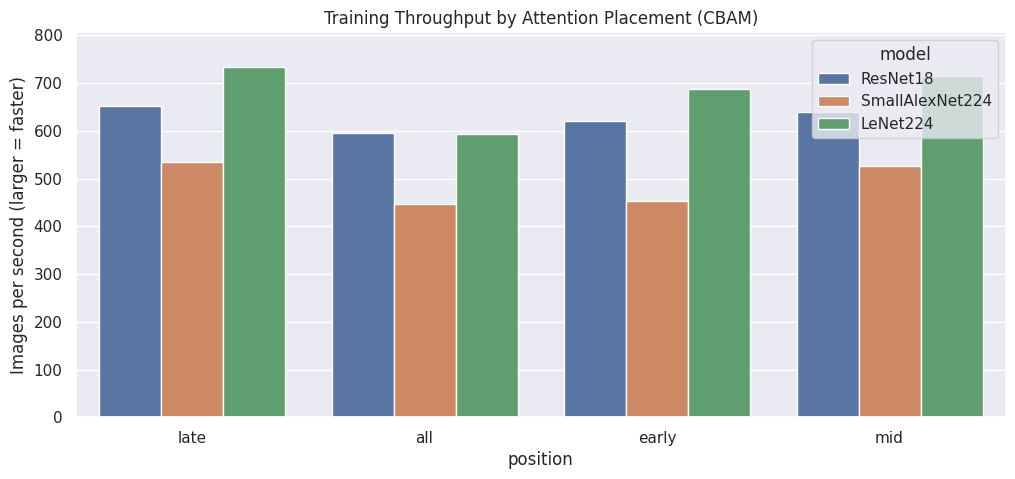

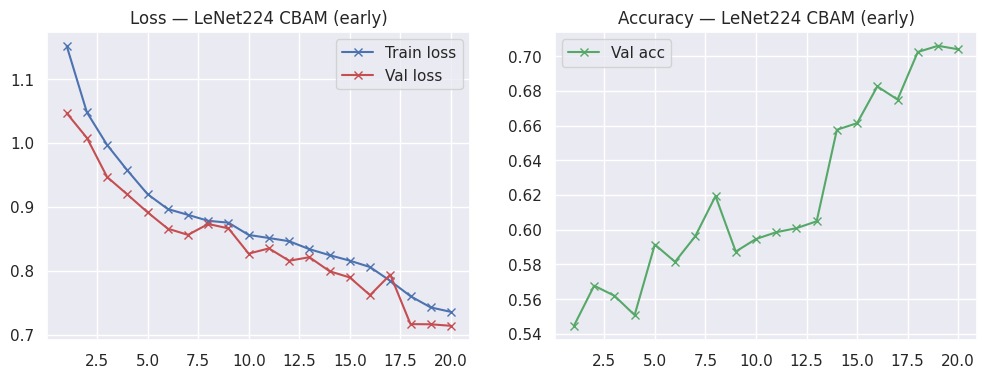

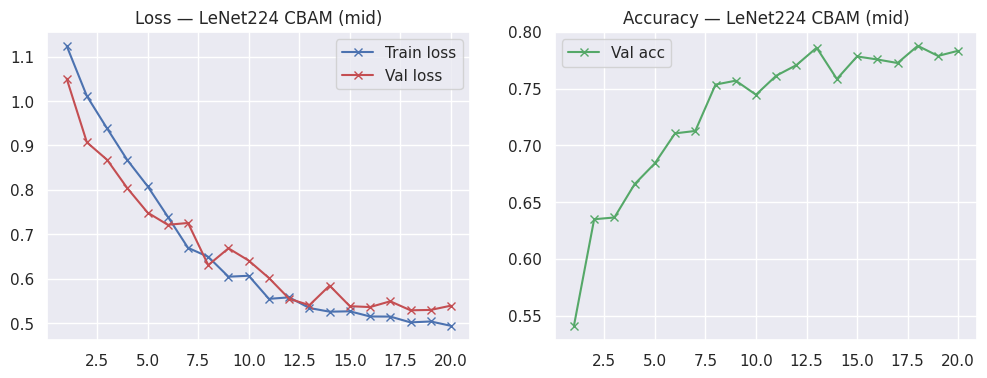

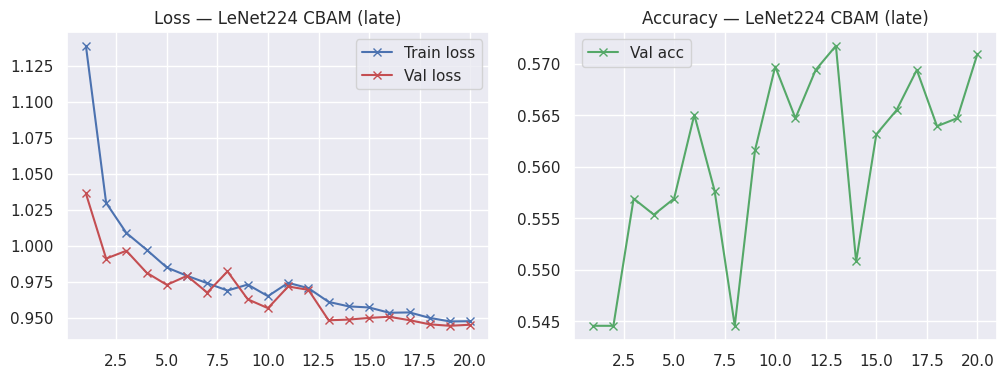

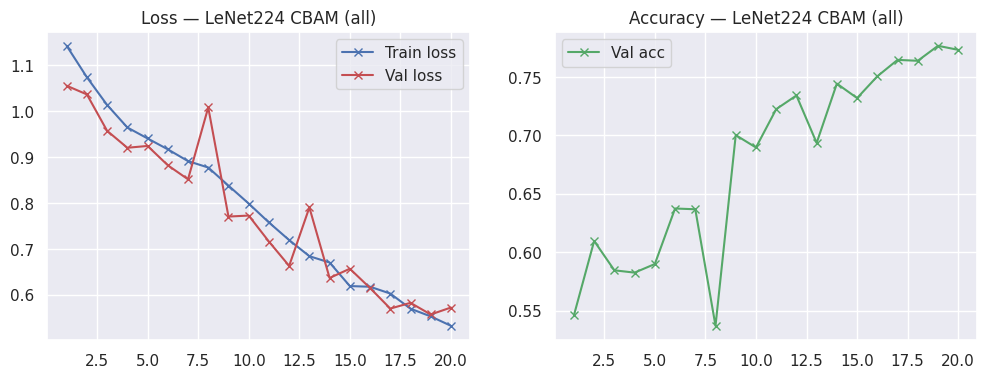

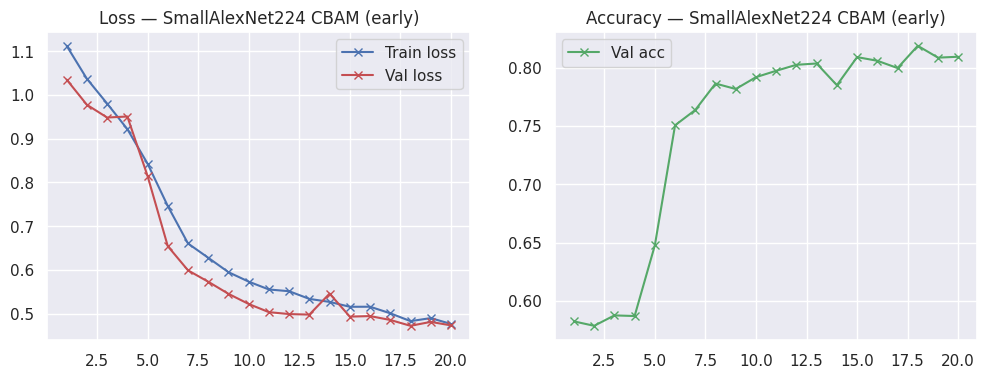

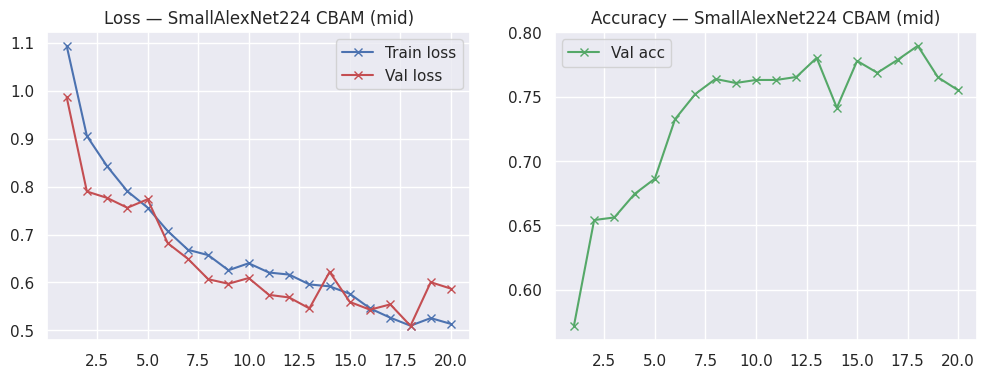

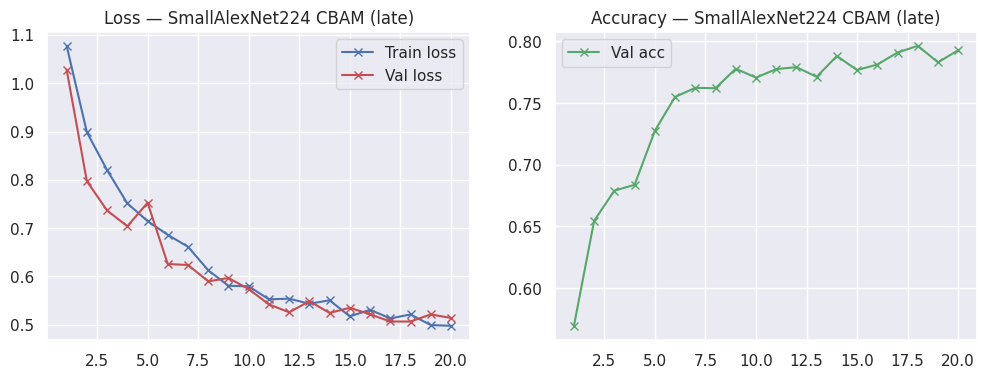

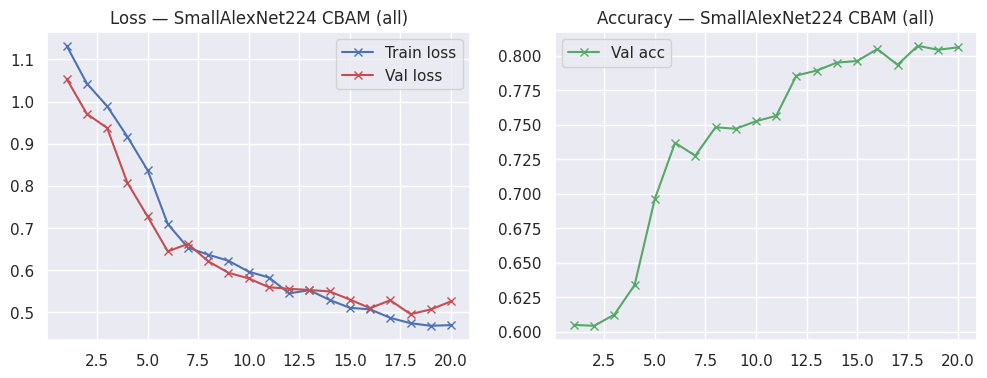

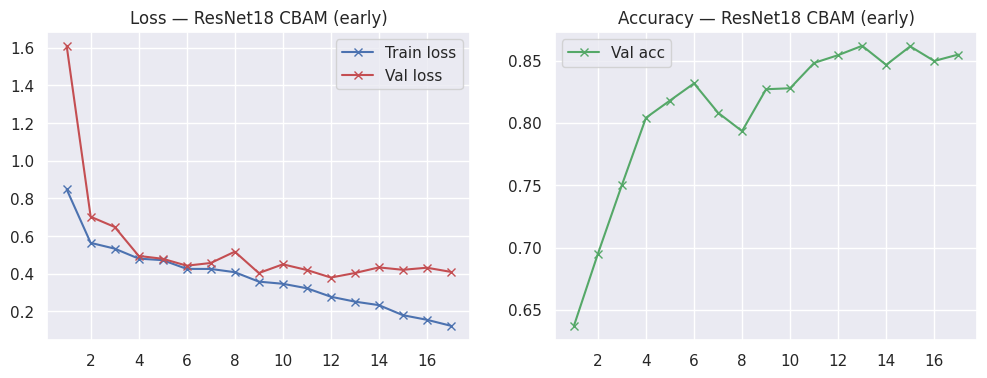

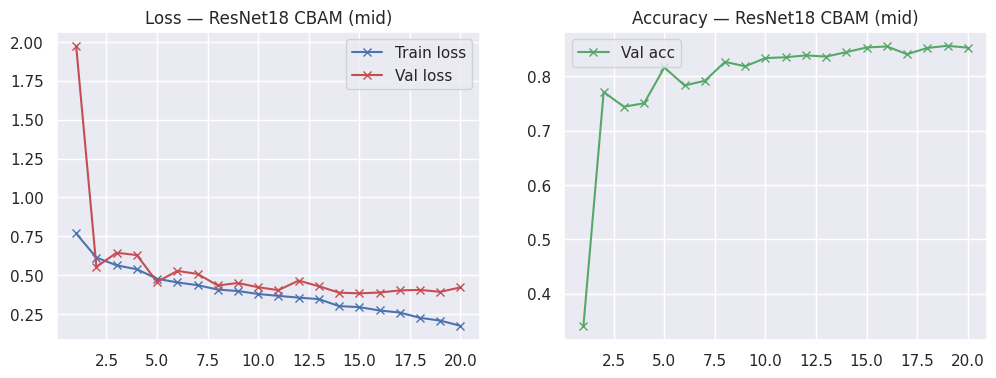

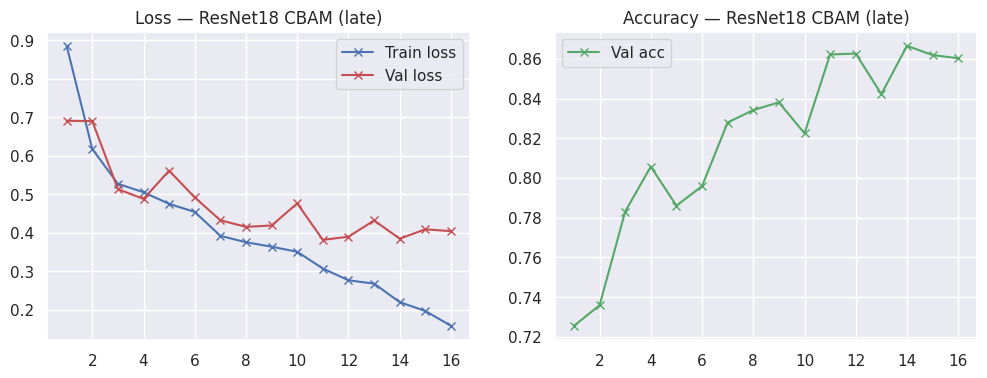

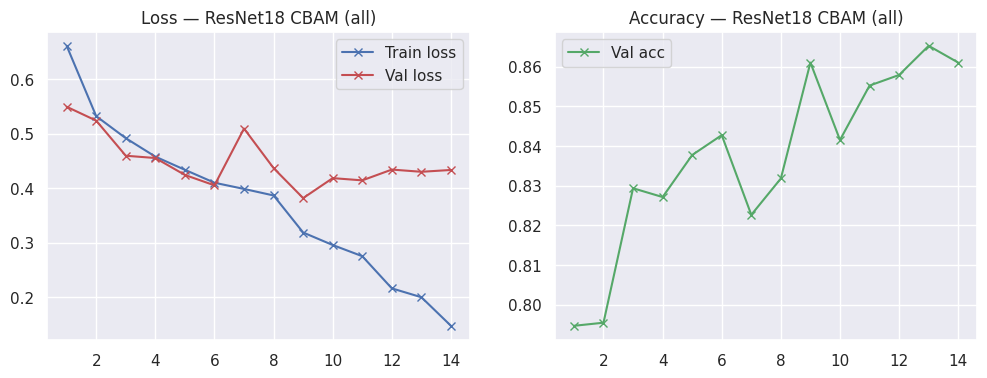

In [ ]:
df_all = pd.DataFrame([{k: v for k, v in r.items() if k != "history"} for r in results])
df_all = df_all.sort_values("best_val_acc", ascending=False).reset_index(drop=True)

out_csv = "road_condition_attention_grid.csv"
df_all.to_csv(out_csv, index=False)
display(df_all)
print("Saved:", out_csv)

df_best = (
    df_all.sort_values("best_val_acc", ascending=False)
    .groupby(["model", "attention_type"], as_index=False)
    .first()
)
display(df_best.sort_values(["model", "attention_type"]))

plt.figure(figsize=(10, 5))
sns.barplot(df_best, x="attention_type", y="best_val_acc", hue="model")
plt.title("Best Validation Accuracy by Attention Type (best placement per model)")
plt.ylabel("Best Val Accuracy")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(df_best, x="attention_type", y="test_acc", hue="model")
plt.title("Test Accuracy by Attention Type (best placement per model)")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(df_best, x="attention_type", y="images_per_sec", hue="model")
plt.title("Training Throughput by Attention Type (best placement per model)")
plt.ylabel("Images per second (larger = faster)")
plt.ylim(0, df_best["images_per_sec"].max() * 1.1 if len(df_best) else 1)
plt.show()

df_pos = df_all[df_all["attention_type"] != "none"].copy()
df_pos["position"] = df_pos["position"].astype(str)

plt.figure(figsize=(12, 5))
sns.barplot(df_pos, x="position", y="best_val_acc", hue="model")
plt.title("Best Validation Accuracy by Attention Placement (CBAM)")
plt.ylabel("Best Val Accuracy")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(df_pos, x="position", y="test_acc", hue="model")
plt.title("Test Accuracy by Attention Placement (CBAM)")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(df_pos, x="position", y="images_per_sec", hue="model")
plt.title("Training Throughput by Attention Placement (CBAM)")
plt.ylabel("Images per second (larger = faster)")
plt.ylim(0, df_pos["images_per_sec"].max() * 1.1 if len(df_pos) else 1)
plt.show()

for r in grid_results:
    title = f"{r['model']} {r['attention_type']} ({r['position']})"
    plot_training_curves(r["history"], title=title)